## Dataset Background & Problem Definition

---

## 1. Background
RMS Titanic adalah kapal penumpang super yang dibangun oleh Harland and Wolff di Belfast, Inggris. Kapal ini diluncurkan pada tahun 1911 dan merupakan yang terbesar di dunia pada saat itu, dirancang untuk memberikan kenyamanan dan kemewahan bagi penumpangnya.

Pada malam 14 April 1912, sekitar pukul 23:40, Titanic menabrak gunung es di Samudra Atlantik Utara, sekitar 375 mil dari Newfoundland. Tabrakan ini menyebabkan kerusakan parah pada lambung kapal, melubangi lima dari enam belas kompartemen kedap airnya. Meskipun Titanic dirancang untuk tetap mengapung jika empat kompartemennya bocor, kerusakan ini menyebabkan kapal mulai tenggelam.

Kapal mulai tenggelam dua jam setelah tabrakan, pada pukul 02:20 tanggal 15 April. Proses evakuasi berlangsung kacau, dengan banyak sekoci diluncurkan dalam keadaan setengah penuh. Hanya 710 dari 2.224 penumpang dan awak yang selamat, sementara lebih dari 1.500 orang tewas, banyak di antaranya karena hipotermia setelah terjatuh ke laut yang sangat dingin.

---

## 2. Study Objective
- Mengidentifikasi Faktor kontribusi paling tinggi penyebab korban jiwa.
- Menganalisa lebih dalam golongan tertentu yang paling banyak kehilangan.

Model berfungsi untuk menganalisa golongan korban jiwa yang paling terdampak dan Menciptakan Hipotesis (Interpretasi) mengapa hal tersebut bisa terjadi.

---

## 3. Problem Definition

### Study Question
> (Interpretasi) Golongan Penumpang yang paling banyak menderita kehilangan nyawa ketika terjadi kecelakaan di kapal berdasarkan Fitur-fiture yang tersedia di dataset.

### Machine Learning Framing
- **Problem Type**: Supervised Learning.
- **Task**: Binary Classification.
- **Target Variable**: `Survived`
    - `Yes (1)` -> Penumpang Selamat.
    - `No (0)` -> Penumpang Tidak Selamat.

Model menghasilkan **probabilitas survived** sebagai dasar pengambilan keputusan.

---

## 4. Input Data

Dataset berisi data historis penumpang dengan kolom sebagai berikut:

### Numerical Features
- **`PassengerId`**
  ID Penumpang (identitas unik tiap penumpang).
- **`Survived`**
  Status Keselamatan / Kelangsungan Hidup (selamat atau tidak selamat).
- **`Pclass`**
  Kelas Penumpang (kelas tiket: 1 = First Class, 2 = Second Class, 3 = Third Class).
- **`Age`**
  Umur.
- **`SibSp`**
  Jumlah Saudara/Kerabat dan Pasangan di Kapal
  (Sibling/Spouse: saudara kandung dan pasangan/suami-istri).
- **`Parch`**
  (Parent/Child: orang tua dan anak).
- **`Fare`**
  Tarif Tiket / Harga Tiket.

---

### Categorical Features
- **`Sex`** 
  Jenis Kelamin.
- **`Ticket`** 
  Nomor Ticket.
- **`Cabin`** 
  Nomor Cabin.
- **`Embarked`** 
  Pelabuhan.

---

### Identifier Features
- **`Name`** 
  Nama.
- **`PassenggerId`** 
  Id Penumpang.

---

### Target Variable
- **`Survived`**
    Status keadaan penumpang (`1` = Penumpang selamat, `0` = Penumpang tidak selamat).

---

## 5. Data Notes & Constraints
- Sumber Dataset: Kaggle.com
- Sumber Informasi: [wikipedia](https://www.bing.com/ck/a?!&&p=e83779fc07e82f923f82a4af228226a632a20766e7a26598fc352f35d4a4f2f2JmltdHM9MTc4MDk2MzIwMA&ptn=3&ver=2&hsh=4&fclid=1928fca4-b86c-6369-0a5e-e9ceb93a6258&psq=tragedi+kapal+titanic&u=a1aHR0cHM6Ly9pZC53aWtpcGVkaWEub3JnL3dpa2kvVGVuZ2dlbGFtbnlhX1JNU19UaXRhbmlj)
- Dataset mengandung **missing values**.
- Terdapat **class imbalance** antara pelanggan selamat dan tidak selamat.

---

## 6. Expected Outcome
- Fitur apa saja yang paling berpengaruh dalam dataset.
- Interpretasi mengapa penumpang berisiko tidak selamat.


# Data Acquistion

---

In [2]:
# import library
import pandas as pd 
import warnings 
warnings.filterwarnings('ignore')

# Overview dataset
df = pd.read_csv('train.csv') 
df 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Features dengan kemungkinan **`Invalid Data`** dengan seleksi < 0: tidak ada / null,
Tidak ditemukan Kolom numerik yang bersifat konstan atau kategori

Tidak ada masalah pada dataset sehingga proses bisa dilanjutkan ke **`Data Understanding & Cleaning`** untuk proses pembersihan lebih lanjut

# Data Understanding & Cleaning

---

In [3]:
# Hapus ident feature
cols = ['PassengerId', 'Ticket']
df = df.drop(columns=cols)

Feature `Name` memang ident feature tetapi **terdapat pola** yang bisa diambil dari Nama setiap Penumpang, yang akan digunakan untuk feature engineering nanti.

In [4]:
# Struktur Data
print(f'Kolom Baris: {df.shape}') 
print() 
df.info() 

Kolom Baris: (891, 10)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Cabin     204 non-null    str    
 9   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(4)
memory usage: 69.7 KB


Nantinya kita akan memisahkan tipe data **`Numerik: float64, int64`** dan tipe data **`Kategori: str`** Nantinya akan dilanjutkan dengan memisahkan **`Numerik antara Continous atau Ordinal(kategori)`** Feature 

In [5]:
# Ringkasan Data
print(f'Ringkasan data \n{df.describe()}')

Ringkasan data 
         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [6]:
(df['Fare'] > 40).sum() # Ada 176 orang

np.int64(176)

Terdapat Kecurigaan terhadap kolom **`Fare`** (biaya ticket) apakah ini kebetulan hanya beberapa orang (Outlier), setelah di cek terdapat 176 orang dari 891 orang di kapal

In [7]:
# Data Duplikat
print(f'Jumlah data duplikat: {df.duplicated().sum()}')

Jumlah data duplikat: 0


Tidak ditemukan data duplikat

In [8]:
# Missing Value Analyst
print(f'Jumlah data kosong: \n{df.isnull().sum().sort_values(ascending=False)}\n') 
print(f'Proporsi Jumlah data kosong: \n{df.isnull().mean().sort_values(ascending=False)}') 

Jumlah data kosong: 
Cabin       687
Age         177
Embarked      2
Survived      0
Pclass        0
Name          0
SibSp         0
Sex           0
Fare          0
Parch         0
dtype: int64

Proporsi Jumlah data kosong: 
Cabin       0.771044
Age         0.198653
Embarked    0.002245
Survived    0.000000
Pclass      0.000000
Name        0.000000
SibSp       0.000000
Sex         0.000000
Fare        0.000000
Parch       0.000000
dtype: float64


Feature / kolom **`Cabin`** tedapat 687 yang kosong kemungkinan besar ini karena penumpang di kapal sebagian besar tidak membeli Cabin untuk mereka tempati dan Kolom **`Age`** terdapat 177 data kosong (mungkin anak balita tidak membayar ticket? sehingga masuk penumpang tetapi dikosongkan), kemungkinan besar untuk kolom **`Age`** dikasih label MNAR, Lalu kolom **`Embarked`** terdapat 2 data kosong, kemungkinan ini terjadi secara random.

In [9]:
# Data Error check

# jumlah unique (Khusus Kategori ya)
print(f'Jumlah Data unik: {df["Sex"].nunique()}')  # Memeriksa jenis pengisi kolom Sex
print() # Memberikan end line

# jenis-jenis Keunikan (Khusus Kategori)
print(f'Isi Data unik: \n{df["Sex"].unique()}') # Memeriksa isi dari jenis pengisi kolom sex sebelumnya



Jumlah Data unik: 2

Isi Data unik: 
<StringArray>
['male', 'female']
Length: 2, dtype: str


Tidak ditemukan data aneh atau data Incosistent dari kolom **`Sex`**

In [10]:
# Value Distribution

# jumlah unique (Khusus Kategori ya)
print(f'Jumlah Data unik: {df["Embarked"].nunique()}') # Memanggil banyaknya nilai unik dari kolom Embarked
print() # Memberikan spasi

# jenis-jenis Keunikan (Khusus Kategori)
print(f'Isi Data unik: \n{df["Embarked"].unique()}') # Memanggil Isi Jenis dari nilai unik kategori

Jumlah Data unik: 3

Isi Data unik: 
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


Tidak ditemukan data aneh atau data Incosistent dari kolom **`Embarked`**

Sudah selesai dengan **`Data Understanding & Cleaning`** Kita lanjutkan dengan mempersiapkan data sebelum di split, Feature Construction untuk menambah nilai informasi dari pelatihan model

In [11]:
# Feature Construction

# FAMILY FEATURE
df['Familysize'] = df['SibSp'] + df['Parch'] + 1 

df['isAlone'] = 0 
df['isSmallFamily'] = 0 
df['isLargeFamily'] = 0 

df.loc[df['Familysize'] == 1, 'isAlone'] = 1 
df.loc[(df['Familysize'] > 1) & (df['Familysize'] < 5), 'isSmallFamily'] = 1
df.loc[df['Familysize'] > 4, 'isLargeFamily'] = 1

# FARE FEATURE
df['FarePerPerson'] = df['Fare'] / df['Familysize']

# CABIN FEATURE
df['HasCabin'] = 0
df.loc[df['Cabin'].notna(), 'HasCabin'] = 1
df['Deck'] = df['Cabin'].str[0].fillna('U')

# NAME FEATURE
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.') 
rare_titles = ['Lady', 'Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'] 
df['Title'] = df['Title'].replace(rare_titles, 'Rare') 
df['Title'] = df['Title'].replace({ 
    'Mlle': 'Miss', 
    'Ms': 'Miss', 
    'Mme': 'Mrs' 
})

# Cek Anak anak
df['isChild'] = 0 
df.loc[df['Age'] <= 1, 'isChild'] = 1 

Feature yang telah dibuat cenderung akan mengalami multicolinearity, oleh kearena itu diperlukan pengecekan korelasi lebih lanjut antara feature dengan feature dan target pada saat EDA 

In [12]:
# melalukan split data (2 / 2 )
from sklearn.model_selection import train_test_split # Import Library Sklearn model selection modul train_test_split

# Define sumber Split data
X = df.drop(columns=["Survived"]) # Definisi X untuk split data yang merupakan feature
y = df["Survived"] # Definisi y Target

# Split Data
X_train, X_test, y_train, y_test = train_test_split( 
			X, # ganti jadi sumber temp
			y, # ganti jadi temp
			test_size = 0.2,
			random_state=42,
			stratify=y
			)
	
# Cek Ukuran Hasil Split Data
print(f'Kolom baris X_train: {X_train.shape}') 
print(f'Kolom baris X_test: {X_test.shape}')
print(f'Kolom baris y_train: {y_train.shape}')
print(f'Kolom baris y_test: {y_test.shape}')

Kolom baris X_train: (712, 18)
Kolom baris X_test: (179, 18)
Kolom baris y_train: (712,)
Kolom baris y_test: (179,)


In [13]:
from sklearn.impute import SimpleImputer
# handling missing value

# 1. Age
imputerAge = SimpleImputer(strategy='median')

X_train['Age'] = imputerAge.fit_transform(X_train[['Age']])
X_test['Age'] = imputerAge.transform(X_test[['Age']])


In [14]:
# 2. Embarked
imputerEmbarked = SimpleImputer(strategy='most_frequent')

X_train['Embarked'] = imputerEmbarked.fit_transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = imputerEmbarked.transform(X_test[['Embarked']]).ravel()

Features **`Age`** beberapa kosong atau missing value karena pembatasan khusus di kapal tersebut, tapi masih mempunyai korelasi kuat sehingga dipertahankan dengan mengisi nilai median dari series tersebut

Fetaure **`Cabin`** mengingat nilai NaN yang sangat banyak dan kemungkinan keadaan penumpang yang memilih untuk tidak mempunyai Cabin akan dilakukan Feature Preprocessing lebih lanjut dengan mengisi NaN dengan 0 atau tidak memiliki Cabin.

Feature **`Embarked`** masih memerlukan Feature Preprocessing lebih lanjut, tetapi mengingat Ukuran dataset dan missing value yang hanya beberapa dari keseluruhan data maka data akan tetap dipertahankan dengan Imputasi nilai modus.

# Preprocessing

---

In [15]:
# Supaya Data aman kita copy dulu

# copy data for EDA and Preprocessing
X_train_eda = X_train.copy()
y_train_eda = y_train.copy()

In [16]:
# Kita tentukan Continous setiap kolom

X_train.tail()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Familysize,isAlone,isSmallFamily,isLargeFamily,FarePerPerson,HasCabin,Deck,Title,isChild
359,3,"Mockler, Miss. Helen Mary ""Ellie""",female,28.5,0,0,7.8792,NaN,Q,1,1,0,0,7.8792,0,U,Miss,0
258,1,"Ward, Miss. Anna",female,35.0,0,0,512.3292,NaN,C,1,1,0,0,512.3292,0,U,Miss,0
736,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,34.3750,NaN,S,5,0,0,1,6.8750,0,U,Mrs,0
462,1,"Gee, Mr. Arthur H",male,47.0,0,0,38.5000,E63,S,1,1,0,0,38.5000,1,E,Mr,0
507,1,"Bradley, Mr. George (""George Arthur Brayton"")",male,28.5,0,0,26.5500,NaN,S,1,1,0,0,26.5500,0,U,Mr,0


In [17]:
# PILIH NUMERIC CONTINUOUS SAJA
num_cols = [c for c in X_train.select_dtypes(include=["int64", "float64"]).columns if X_train[c].nunique() > 4 ] 

num_cols

['Age', 'SibSp', 'Parch', 'Fare', 'Familysize', 'FarePerPerson']

Pemilihan feature **`Numerik`** dengan kategori dummy atau **`Numerik`** tetapi keadaannya Kategori tetap harus dipisahkan walaupun kekurangan data karena perlakuan **`FE`** kedepannya akan berbeda.

Pada Tahap ini Kita bisa melakukan Handling Outlier tetapi untuk dataset ini kita tidak akan melakukannya mengingat Jumlah data yang dimiliki tidak sampai 1000

# Exploratory Data Analysis (EDA)

---

In [18]:
# Kita gabungkan X_train dan y_train untuk melakukan eda
df_train_eda = pd.concat([X_train_eda, y_train_eda], axis=1)
df_train_eda.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Familysize,isAlone,isSmallFamily,isLargeFamily,FarePerPerson,HasCabin,Deck,Title,isChild,Survived
692,3,"Lam, Mr. Ali",male,28.5,0,0,56.4958,NaN,S,1,1,0,0,56.4958,0,U,Mr,0,1
481,2,"Frost, Mr. Anthony Wood ""Archie""",male,28.5,0,0,0.0000,NaN,S,1,1,0,0,0.0000,0,U,Mr,0,0
527,1,"Farthing, Mr. John",male,28.5,0,0,221.7792,C95,S,1,1,0,0,221.7792,1,C,Mr,0,0
855,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,9.3500,NaN,S,2,0,1,0,4.6750,0,U,Mrs,0,1
801,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,26.2500,NaN,S,3,0,1,0,8.7500,0,U,Mrs,0,1


## Univariate Analysis

---

Check distribusi data menggunakan visualisasi

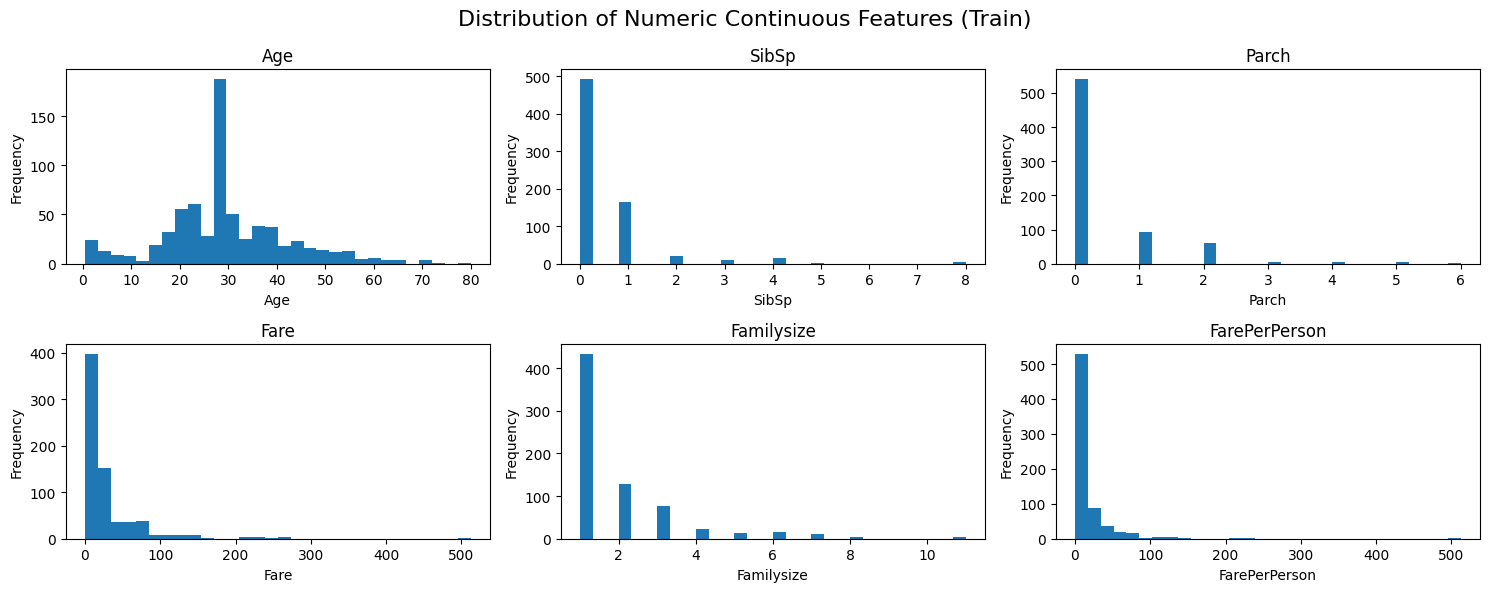

In [19]:
# Import Library
import matplotlib.pyplot as plt 
import math 

n_cols = 3  
n_rows = math.ceil(len(num_cols) / n_cols) 

fig, axes = plt.subplots(  
    n_rows, 
    n_cols, 
    figsize=(n_cols * 5, n_rows * 3)  
)

axes = axes.flatten() 

for i, col in enumerate(num_cols): 
    axes[i].hist(df_train_eda[col], bins=30) 
    axes[i].set_title(col) 
    axes[i].set_xlabel(col) 
    axes[i].set_ylabel("Frequency") 


for j in range(i + 1, len(axes)): 
    fig.delaxes(axes[j])

fig.suptitle(
    "Distribution of Numeric Continuous Features (Train)", 
    fontsize=16 
)

plt.tight_layout() 
plt.show() 

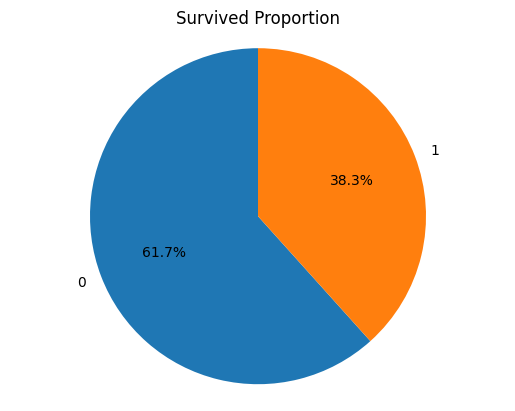

In [20]:
# hitung proporsi
survived_counts = df_train_eda['Survived'].value_counts(normalize=True).sort_index()

# pie chart
plt.figure()
plt.pie(
    survived_counts.values,
    labels=survived_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Survived Proportion')
plt.axis('equal')
plt.show()

Data Imbalance, tapi tidak parah dipertimbangkan untuk melakukan penyesuaian parameter, data, dan model terlebih dahulu sebelum melakukan resampling pada data target.

## Bivariate Analysis

---

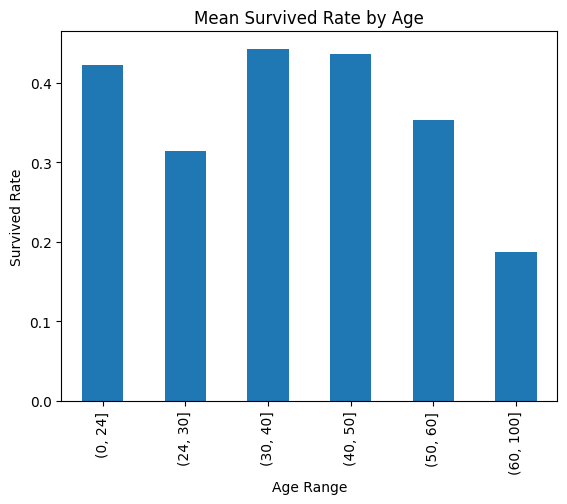

In [21]:
# binning Age
df_train_eda['age_bin'] = pd.cut(
    df_train_eda['Age'],
    bins=[0, 24, 30, 40, 50, 60, 100],
    ordered=True
)

# age_survival_rate
age_churn = (
    df_train_eda
    .groupby('age_bin', observed=True)['Survived']
    .mean()
    .sort_index()
)

# plot
plt.figure()
age_churn.plot(kind='bar')
plt.title('Mean Survived Rate by Age')
plt.xlabel('Age Range')
plt.ylabel('Survived Rate')
plt.show()

Age menunjukkan hubungan non-linear terhadap survived. Survive rate relatif cukup tinggi pada rentang usia 0 sampai 24 tahun dan 30 sampai 60 tahun namun menurun secara signifikan pada rentang usia 20 sampai 30 dan segmen usi >= 60 tahun. Hal ini mengindikasikan adanya kemungkinan keadaan ketika anak kecil dan remaja dan dewasa hingga orang tua (30 >= 60) untuk didahulukan dan rentang usia dewasa 30 (24 >= 30) dan manula (60 >= 100) yang tidak dapat ditangkap dengan satu koefisien linear, sehingga Age lebih tepat dimodelkan melalui binning untuk merepresentasikan perbedaan risiko antar segmen usia.

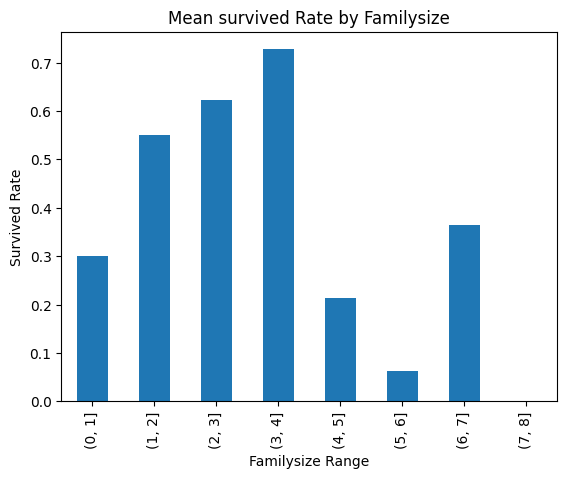

In [22]:
# binning Familysize
df_train_eda['Familysize_bin'] = pd.cut(
    df_train_eda['Familysize'],
    bins=[0, 1, 2, 3, 4, 5, 6, 7, 8],
    ordered=True
)

# familysize survival rate 
Familysize = (
    df_train_eda
    .groupby('Familysize_bin', observed=True)['Survived']
    .mean()
    .sort_index()
)

# plot
plt.figure()
Familysize.plot(kind='bar')
plt.title('Mean survived Rate by Familysize')
plt.xlabel('Familysize Range')
plt.ylabel('Survived Rate')
plt.show()

Familysize menunjukkan hubungan non-linear terhadap survived. Survive rate relatif cukup konsisten meningkat pada rentang 0 hingga 3 orang dan kembali mengalami penurunan hingga Familysize beranggotakan 6 orang dan kembali meningkat untuk Familysize 6 hingga 7 orang yang tidak dapat ditangkap dengan satu koefisien linear, sehingga Familysize lebih tepat dimodelkan melalui binning untuk merepresentasikan perbedaan risiko antar segmen usia.

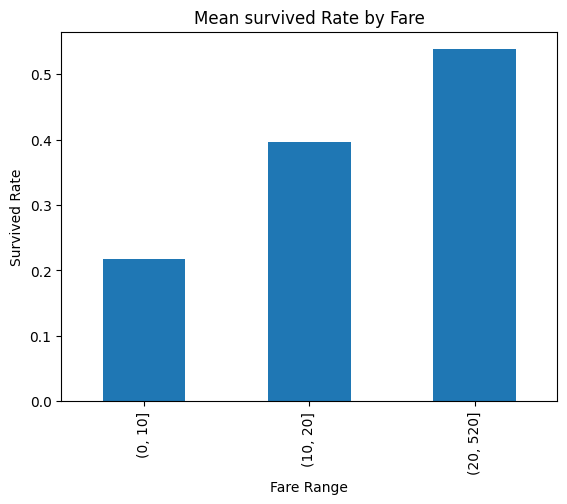

In [23]:
# binning fare
df_train_eda['Fare_bin'] = pd.cut(
    df_train_eda['Fare'],
    bins=[0, 10, 20, 520],
    ordered=True
)

# fare survival rate
Fare = (
    df_train_eda
    .groupby('Fare_bin', observed=True)['Survived']
    .mean()
    .sort_index()
)

# plot
plt.figure()
Fare.plot(kind='bar')
plt.title('Mean survived Rate by Fare')
plt.xlabel('Fare Range')
plt.ylabel('Survived Rate')
plt.show()

Semakin mahal ticket nya semakin tinggi tingkat keselamatannya

## Multivariate Analysis

---

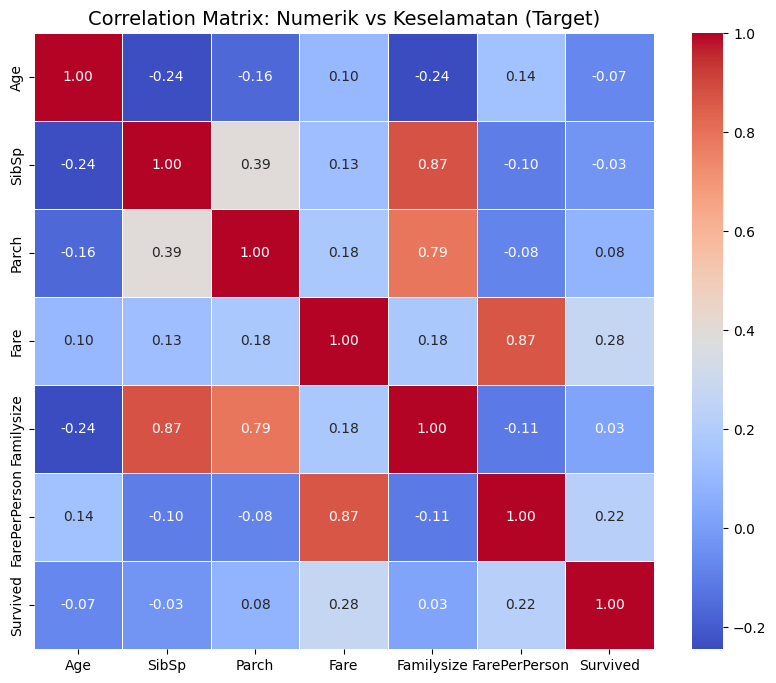

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pastikan 'Survived' digabung dengan fitur numerikmu untuk dicek
cols_to_check = num_cols + ['Survived'] 

# 2. Hitung korelasi
corr = df_train_eda[cols_to_check].corr()

# 3. Visualisasi modern dengan angka
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True,        
            cmap='coolwarm',   
            fmt=".2f",         
            linewidths=0.5)

plt.title('Correlation Matrix: Numerik vs Keselamatan (Target)', fontsize=14)
plt.show()

**`SibSP`** dan **`Parch`** sangat redundan terhadap **`Familysize`** sehingga harus dilakukan pemeriksa lebih lanjut dengan multicolinearity sedangkan **`Fare`** memiliki korelasi lemah dengan **`Pclass`**

# Feature Engineering

---

In [25]:
# Hapus feature yang tidak relevant / bermasalah

DROP_PREFIXES = [
    # redundant feature
    "SibSp",
    "Parch",
    "isLargeFamily",
    "isAlone",
    "Fare",
    "isChild",
    "isSmallFamily",

    # High Cardinality
    "Cabin",
    "HasCabin",

    # Identifiers
    "Name",
    "Ticket",
    "TicketPrefix",
    "PassengerId",

    # Bin
    "Fare_bin",
    "Familysize_bin",
    "age_bin"
]

KEEP_COLS_EXPLICIT = [
    "Familysize",
    "FarePerPerson"
           
]


def exclude_columns_encoded(df: pd.DataFrame) -> pd.DataFrame:
    cols_to_drop = []

    # looping semua kolom
    for col in df.columns:
        for prefix in DROP_PREFIXES:
            if col.startswith(prefix):
                cols_to_drop.append(col)

    # Safety: ensure kept prefixes are NOT dropped
    for col in df.columns:
        for keep in KEEP_COLS_EXPLICIT:
            if col.startswith(keep) and col in cols_to_drop:
                cols_to_drop.remove(col)

    return df.drop(columns=cols_to_drop)

In [26]:
# jalankan fungsi
X_train = exclude_columns_encoded(X_train)
X_test  = exclude_columns_encoded(X_test)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (712, 8)
Test shape : (179, 8)


In [27]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Inisiasi Encoder 
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# 2. Tentukan kolom kategorikal
cat_cols = ['Sex', 'Embarked', 'Title', 'Deck']

# 3. Fit & Transform HANYA di Data Train
train_encoded = ohe.fit_transform(X_train[cat_cols])
train_encoded_df = pd.DataFrame(
    train_encoded, 
    columns=ohe.get_feature_names_out(cat_cols), 
    index=X_train.index
)

# 4. Transform HANYA di Data Test (Menggunakan ingatan dari Train)
test_encoded = ohe.transform(X_test[cat_cols])
test_encoded_df = pd.DataFrame(
    test_encoded, 
    columns=ohe.get_feature_names_out(cat_cols), 
    index=X_test.index
)

# 5. Gabungkan hasil encoding ke data asli, dan buang teks aslinya
X_train = pd.concat([X_train.drop(columns=cat_cols), train_encoded_df], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), test_encoded_df], axis=1)

In [28]:
import joblib
joblib.dump(ohe, 'OneHotEncoder_titanic.joblib')

['OneHotEncoder_titanic.joblib']

In [29]:
# temukan kolom numerik
num_cols = X_train.select_dtypes(include="number").columns

# exclude data ordinal
cont_cols = [
    c for c in num_cols
    if X_train[c].nunique() > 5
]

cont_cols

['Age', 'Familysize', 'FarePerPerson']

In [30]:
from sklearn.preprocessing import StandardScaler
import numpy as np

log_cols = ["Age"]

# FIX DOMAIN LOG
for df in [X_train, X_test]:
    for col in log_cols:
        df[col] = df[col].clip(lower=0)

# LOG TRANSFORM
for df in [X_train, X_test]:
    for col in log_cols:
        df[col] = np.log1p(df[col])

# SCALING (FIT DI TRAIN)
scaler = StandardScaler()
X_train[cont_cols] = scaler.fit_transform(X_train[cont_cols])
X_test[cont_cols]  = scaler.transform(X_test[cont_cols])


In [31]:
import joblib
joblib.dump(scaler, 'Scaler_titanic.joblib')

['Scaler_titanic.joblib']

## Modeling 

---

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score

# Modeling
model = KNeighborsClassifier(
    n_neighbors=27,
    weights='distance',
    metric='minkowski',
    p=2,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred_model=model.predict(X_test)
print(f'hasil prediksi:{recall_score(y_test, y_pred_model)}')

hasil prediksi:0.7101449275362319


In [33]:
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_model))


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



Menunjukan bias model terhadap second class

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# 1. Inisiasi model dasar
knn = KNeighborsClassifier()

# 2. Tentukan Peta Parameter (Grid)
param_grid = {
    'n_neighbors': range(3, 22, 2), 
    'weights': ['uniform', 'distance'], 
    'p': [1, 2] 
}

# 3. Rakit Mesin Pencari (GridSearchCV)
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,                
    scoring='recall',    
    n_jobs=-1            
)

# 4. Latih mesin pencari HANYA pada data train
print("Memulai pencarian parameter optimal...")
grid_search.fit(X_train, y_train)

# 5. Ekstrak Pemenangnya
best_knn = grid_search.best_estimator_

print("=========================================")
print("Hyperparameter Terbaik :", grid_search.best_params_)
print("Skor Recall (Train CV) :", round(grid_search.best_score_ * 100, 2), "%")
print("=========================================")

Memulai pencarian parameter optimal...
Hyperparameter Terbaik : {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
Skor Recall (Train CV) : 73.27 %


In [35]:
import joblib

# Misalkan 'rf_model' adalah model yang sudah kamu latih
joblib.dump(best_knn, 'KlassifikasiSederhana_Presentasi.joblib')

['KlassifikasiSederhana_Presentasi.joblib']

In [36]:
import pandas as pd
import numpy as np

def terminal_titanic():
    print("=============================================")
    print("   SISTEM PREDIKSI KESELAMATAN TITANIC       ")
    print("=============================================")
    print("Masukkan data penumpang baru:")
    
    try:
        # 1. Mengambil Input Lengkap
        pclass = int(input("Kelas Tiket (1, 2, atau 3)       : "))
        sex = input("Jenis Kelamin (male/female)        : ").strip().lower()
        age = float(input("Umur (angka)                       : "))
        sibsp = int(input("Jumlah Saudara/Pasangan            : "))
        parch = int(input("Jumlah Orang Tua/Anak              : "))
        fare = float(input("Harga Total Tiket ($)              : "))
        embarked = input("Pelabuhan (S/C/Q)                  : ").strip().upper()
        title = input("Gelar (Mr/Mrs/Miss/Master/Rare)    : ").strip()
        deck = input("Dek Kabin (B/C/D/E/F/G/T/U)        : ").strip().upper()
        
        print("\n[INFO] Memproses data ke dalam mesin KNN...")
        
        # 2. Menerapkan Logika Feature Engineering
        family_size = sibsp + parch
        fare_per_person = fare / (family_size + 1)
        
        # Penamaan harus presisi (Familysize dengan s kecil)
        input_data = pd.DataFrame({
            'Pclass': [pclass],
            'Age': [age],
            'Sex': [sex],
            'Embarked': [embarked],
            'Title': [title],
            'Deck': [deck],
            'Familysize': [family_size],
            'FarePerPerson': [fare_per_person]
        })
        
        # 3. Proses One-Hot Encoding
        cat_cols = ['Sex', 'Embarked', 'Title', 'Deck']
        encoded_features = ohe.transform(input_data[cat_cols])
        encoded_df = pd.DataFrame(
            encoded_features, 
            columns=ohe.get_feature_names_out(cat_cols),
            index=input_data.index
        )
        
        # Gabungkan dan buang teks asli
        input_final = pd.concat([input_data.drop(columns=cat_cols), encoded_df], axis=1)
        
        # 4. KUNCI REKAYASA: Sinkronisasi 19 Kolom X_train
        input_final = input_final.reindex(columns=X_train.columns, fill_value=0)
        
        # 5. SURGICAL SCALING: Hanya menskalakan 3 kolom kontinyu!
        cont_cols = ['Age', 'Familysize', 'FarePerPerson']
        input_final[cont_cols] = scaler.transform(input_final[cont_cols])
        
        # 6. Prediksi Akhir dengan Model Terbaik
        prediksi = best_knn.predict(input_final)
        
        print("=============================================")
        if prediksi[0] == 1:
            print(">> HASIL: PENUMPANG DIPREDIKSI [SELAMAT] (SURVIVED) <<")
        else:
            print(">> HASIL: PENUMPANG DIPREDIKSI [TENGGELAM] (NOT SURVIVED) <<")
        print("=============================================")
            
    except Exception as e:
        print(f"\n[ERROR] Komputasi gagal. Detail: {e}")

In [37]:
terminal_titanic()

   SISTEM PREDIKSI KESELAMATAN TITANIC       
Masukkan data penumpang baru:

[INFO] Memproses data ke dalam mesin KNN...
>> HASIL: PENUMPANG DIPREDIKSI [TENGGELAM] (NOT SURVIVED) <<
